In [240]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import integrate
import glob
import os
from scipy.signal import find_peaks
import uncertainties.unumpy as unp
import constants as c

class SignalHandler:
    def __init__(self, file_name):
        self.tV, self.V, self.tI, self.I = self.get_signal(file_name)

    def get_signal(self, file_name):
        df = pd.read_csv(f'{c.ROOT}/{file_name}', index_col=0)
        t_volt, volt = [np.asarray(df[f'Tiempo CH{c.CH_VOLT}']), 
                        np.asarray(df[f'Voltaje CH{c.CH_VOLT}'])]
        t_istr, istr = [np.asarray(df[f'Tiempo CH{c.CH_ISTR}']), 
                1/c.R * np.asarray(df[f'Voltaje CH{c.CH_ISTR}'])]
        return t_volt, volt, t_istr, istr


class SignalReff(SignalHandler):
    def __init__(self, file):
        super().__init__(file)
        self.Vpp, self.Vpp_err, self.T, self.T_err = self.fit_sin()

    def fit_sin(self):
        def sin(x, A, T, p, B): return A*np.sin(2*np.pi/T*x + p) + B
        initialGuess = [7500, 1/8000, 0, 10000]
        popt, pcov = curve_fit(sin, self.tV, self.V, p0=initialGuess)
        perr = np.sqrt(np.diag(pcov))
        A, T, p, B = popt
        A_err, T_err, p_err, B_err = perr
        return 2*A, 2*A_err, T, T_err
    

class SignalZoom(SignalHandler):
    def __init__(self, file_zoom, T):
        super().__init__(file_zoom)
        self.t, self.I, self.V = self.filter()
        self.P_avg = self.get_power(T)
        self.I_avg = self.get_current()
    
    def filter(self):
        dt = 50
        # 0.005 np.max(self.I)/2
        #indices =  np.where(self.I > 0.005)[0]
        #indices =  np.where(self.I/np.max(self.I) > 0.2)[0]
        indices, _ = find_peaks((self.I/np.max(self.I))**2, height=0.15)
        i, f = indices[0] - dt, indices[-1] + dt
        t_filter, y = np.linspace([self.tI[i], np.mean(self.I[i-dt:i])], [self.tI[f], np.mean(self.I[f:f+dt])], f-i).T
        I_filter = self.I[i:f] - y
        V_filter = self.V[i:f]
        return t_filter, I_filter, V_filter
    
    def get_power(self, T):
        return integrate.simpson(self.I * self.V, x=self.t) / T
    
    def get_current(self):
        return np.mean(self.I)
    
    
class Signals:
    def __init__(self, folder):
        self.signals_reff, self.signals_zoom = self.get_signals(folder)
        self.P_avg = self.get_avg_power()
        self.V_vpp = self.get_avg_voltage()
        self.I_avg = self.get_avg_current()

    def get_signals(self, folder):
        files = glob.glob(os.path.join(c.ROOT, folder, '*.csv'))
        signals_reff = [SignalReff(f'{folder}/{os.path.basename(file)}') for file in files if 'reff' in os.path.basename(file)]
        signals_zoom = [SignalZoom(f'{folder}/{os.path.basename(file)}', signals_reff[0].T) for file in files if 'reff' not in os.path.basename(file)]
        return signals_reff, signals_zoom
    
    def get_avg_power(self):
        P_avg = np.mean([s.P_avg for s in self.signals_zoom], axis=0)
        P_std = np.std([s.P_avg for s in self.signals_zoom], axis=0)
        return unp.uarray(P_avg, P_std)

    def get_avg_voltage(self):
        V_vpp = np.mean([s.Vpp for s in self.signals_reff], axis=0)
        V_std = np.mean([s.Vpp_err for s in self.signals_reff], axis=0)
        return unp.uarray(V_vpp, V_std)
    
    def get_avg_current(self):
        I_avg = np.mean([s.I_avg for s in self.signals_zoom], axis=0)
        I_std = np.std([s.I_avg for s in self.signals_zoom], axis=0) # Dudas, ¿asi se calculaba el error del promedio de un promedio? Además, estamos con std de numpy que está sesgado
        return unp.uarray(I_avg, I_std)
    
    def __repr__(self):
        return f'''
                    I = {self.I_avg * 1000} mA
                    V = {self.V_vpp / 1000} kV
                    P = {self.P_avg} W'''

In [241]:
Signals('11-06/tratamiento-e3').P_avg

array(0.6634101990617709+/-0.3163900176627626, dtype=object)

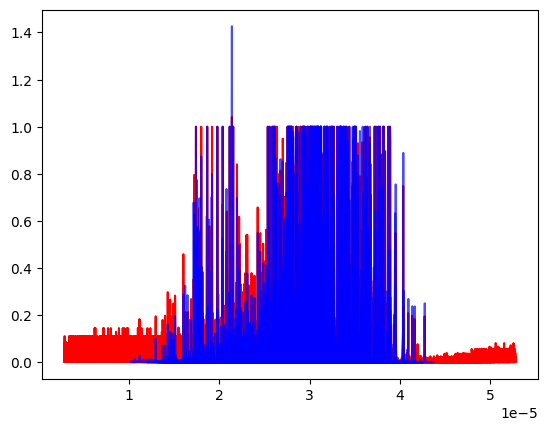

In [243]:
import matplotlib.pyplot as plt
import constants as c


i=0
#sr = SignalReff(f'18-06/tratamiento-e4-vidrio/reff-e4-vidrio 2024-06-18 15h 38m 05s.csv')
for file in os.listdir(f'{c.ROOT}/11-06/tratamiento-e3/'):
        if file.endswith('.csv') and 'reff' not in file:
            sh = SignalHandler(f'11-06/tratamiento-e3/{os.path.basename(file)}')
            sz = SignalZoom(f'11-06/tratamiento-e3/{os.path.basename(file)}',1)

            plt.plot(sh.tI, (sh.I/np.max(sh.I))**2, 'red', alpha=1, zorder=1)
            plt.plot(sz.t, (sz.I/np.max(sz.I))**2, 'blue', alpha=0.7, zorder=2)
            i+=1
            

In [207]:
file = 'tratamiento-e3 2024-06-11 17h 39m 27s.csv'
sh = SignalHandler(f'11-06/tratamiento-e3/{file}')
sz = SignalZoom(f'11-06/tratamiento-e3/{file}',1)

dt = 50
indices, _ = find_peaks((sh.I/np.max(sh.I))**2, height=0.15)
print(indices)
#i, f = indices[0] - dt, indices[-1] + dt
#t_filter, y = np.linspace([self.tI[i], np.mean(self.I[i-dt:i])], [self.tI[f], np.mean(self.I[f:f+dt])], f-i).T
#I_filter = self.I[i:f] - y
#V_filter = self.V[i:f]
print(np.max(sh.I))
plt.plot(sh.tI, (sh.I/np.max(sh.I))**2, 'red')
plt.plot(sz.t, (sz.I/np.max(sh.I))**2, 'blue')

[]


TypeError: unsupported operand type(s) for /: 'NoneType' and 'int'